In [1]:
import numpy as np
import matplotlib.pyplot as plt
import librosa
import librosa.display
import soundfile as sf
import scipy.signal

# Konfigurasi ukuran plot default
plt.rcParams['figure.figsize'] = (12, 4)

## 1. Perekaman Suara Berita di Depan Sumber Derau Statis
Pada tahap ini, berkas rekaman suara (`audio_original.wav`) dimuat menggunakan `librosa` dengan parameter `sr=None` agar laju sampel (*sample rate*) asli dari alat perekam tetap dipertahankan.

In [3]:
file_path = 'audio_original.wav'

# Memuat audio tanpa mengubah sample rate bawaan (sr=None)
y, sr = librosa.load(file_path, sr=None)

# Perhitungan durasi
durasi = len(y) / sr

print("=== INSPEKSI AWAL METADATA AUDIO ===")
print(f"Laju Sampel Asli (fs) : {sr} Hz")
print(f"Durasi Audio          : {durasi:.2f} detik")
print(f"Total Sampel          : {len(y)} sampel")
print(f"Amplitudo Minimum     : {np.min(y):.4f}")
print(f"Amplitudo Maksimum    : {np.max(y):.4f}")

=== INSPEKSI AWAL METADATA AUDIO ===
Laju Sampel Asli (fs) : 48000 Hz
Durasi Audio          : 20.36 detik
Total Sampel          : 977280 sampel
Amplitudo Minimum     : -0.4603
Amplitudo Maksimum    : 0.6161


## 2. Visualisasi Audio 4 Dimensi
Bagian ini membedah sinyal suara ke dalam empat representasi: domain waktu (Waveform), domain frekuensi (Spektrum FFT), gabungan waktu-frekuensi (Spektrogram STFT), dan skala perseptual manusia (Mel-Spektrogram).

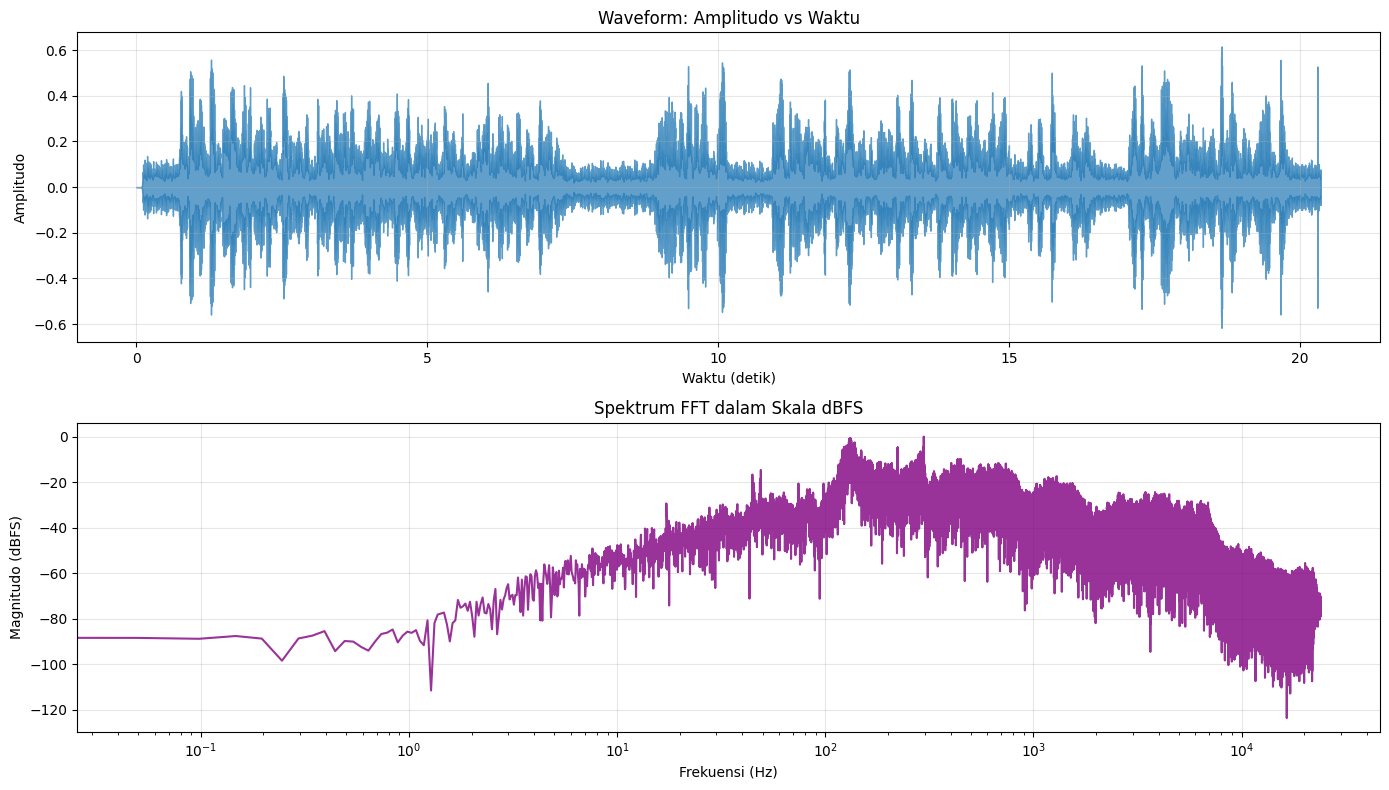

In [4]:
plt.figure(figsize=(14, 8))

# 2.1 Waveform (Amplitudo vs Waktu)
plt.subplot(2, 1, 1)
librosa.display.waveshow(y, sr=sr, alpha=0.7)
plt.title('Waveform: Amplitudo vs Waktu')
plt.xlabel('Waktu (detik)')
plt.ylabel('Amplitudo')
plt.grid(True, alpha=0.3)

# 2.2 Spektrum FFT (dBFS Terkalibrasi)
plt.subplot(2, 1, 2)
# Menghitung Fast Fourier Transform (hanya frekuensi positif)
fft_out = np.fft.rfft(y)
freqs = np.fft.rfftfreq(len(y), d=1/sr)

# Menghitung Magnitudo dan mengonversi ke dBFS
magnitudo = np.abs(fft_out)
# Menghindari log(0) dengan menambahkan nilai sangat kecil (eps)
magnitudo = np.maximum(magnitudo, np.finfo(float).eps)
dbfs = 20 * np.log10(magnitudo / np.max(magnitudo))

plt.plot(freqs, dbfs, color='purple', alpha=0.8)
plt.title('Spektrum FFT dalam Skala dBFS')
plt.xlabel('Frekuensi (Hz)')
plt.ylabel('Magnitudo (dBFS)')
plt.xscale('log') # Skala logaritmik agar frekuensi rendah terlihat jelas
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**Analisis Waveform:** Dari grafik waveform, bagian hening (hanya berisi noise statis) terlihat memiliki amplitudo yang kecil namun konstan secara visual, sementara saat ada suara bacaan literatur, terlihat lonjakan amplitudo yang dinamis.

**Analisis Spektrum FFT:** Pada kurva spektrum, energi tertinggi (puncak magnitudo yang mendekati 0 dBFS) tidak berada di frekuensi sangat rendah, melainkan terpusat pada kisaran 200 Hz hingga 500 Hz. Area ini kemungkinan besar merupakan gabungan dari frekuensi fundamental vokal manusia (saat membaca berita) dan resonansi utama dari derau statis di latar belakang. Sementara itu, komponen frekuensi sangat rendah di bawah 100 Hz terlihat memiliki energi yang jauh lebih kecil (di bawah -40 dBFS).

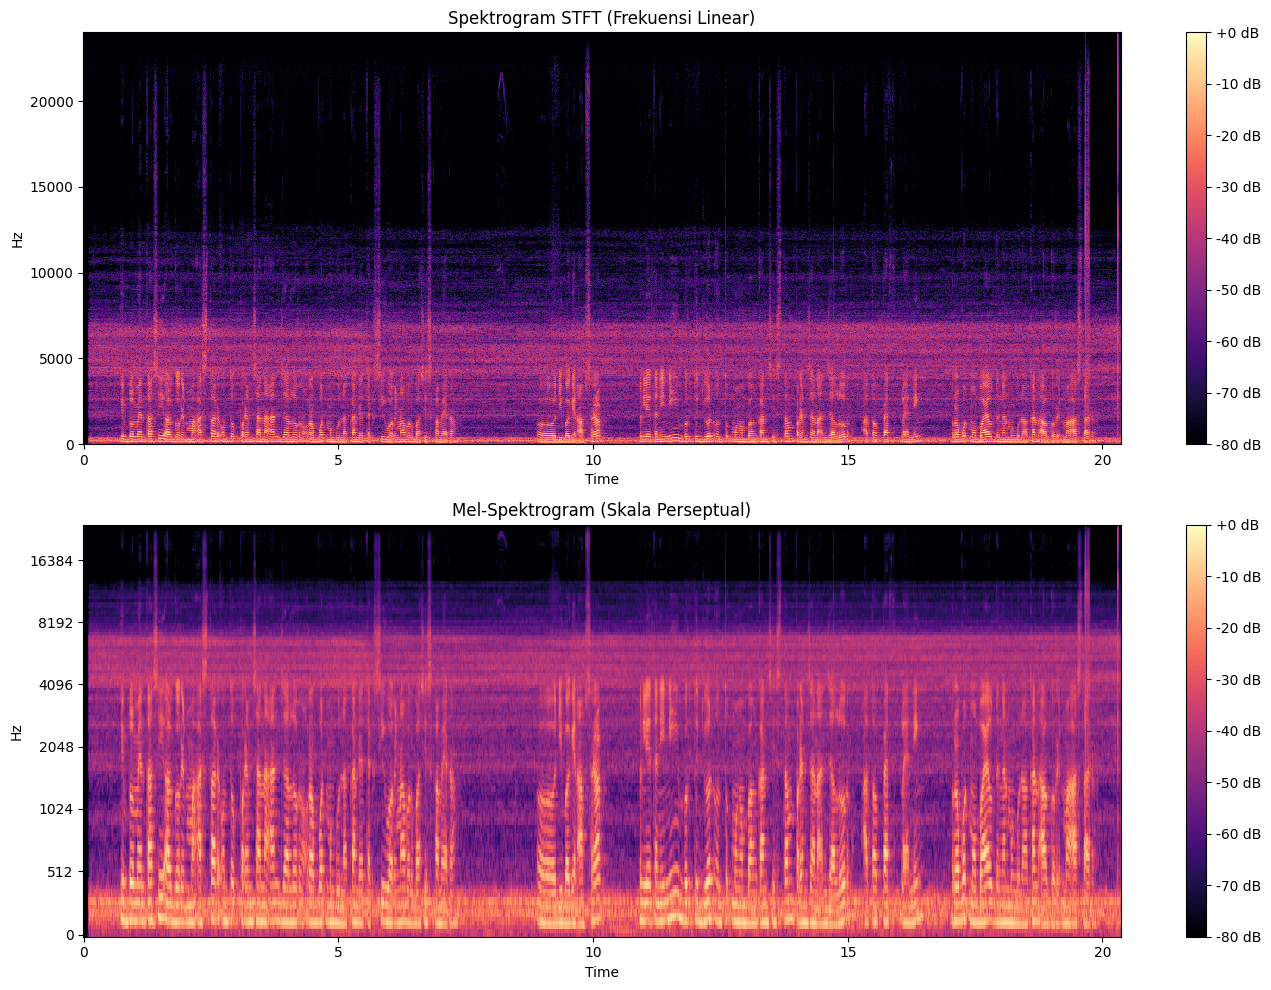

In [5]:
plt.figure(figsize=(14, 10))

# Menghitung Short-Time Fourier Transform (STFT)
D = librosa.stft(y)
# Konversi amplitudo ke Decibel
S_db = librosa.amplitude_to_db(np.abs(D), ref=np.max)

# 2.3 Spektrogram STFT
plt.subplot(2, 1, 1)
librosa.display.specshow(S_db, sr=sr, x_axis='time', y_axis='hz')
plt.colorbar(format='%+2.0f dB')
plt.title('Spektrogram STFT (Frekuensi Linear)')

# 2.4 Mel-Spektrogram
plt.subplot(2, 1, 2)
S_mel = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128)
S_mel_db = librosa.power_to_db(S_mel, ref=np.max)
librosa.display.specshow(S_mel_db, sr=sr, x_axis='time', y_axis='mel')
plt.colorbar(format='%+2.0f dB')
plt.title('Mel-Spektrogram (Skala Perseptual)')

plt.tight_layout()
plt.show()

**Analisis Spektrogram STFT:** Derau statis dari kipas angin tampak jelas sebagai garis horizontal terang (energi stabil berulang) yang membentang dari awal hingga akhir waktu di frekuensi rendah.

**Analisis Mel-Spektrogram:** Ketika mengubah sumbu Y menggunakan skala Mel, pita frekuensi (*formants*) dari vokal pembaca berita terlihat jauh lebih padat dan jelas. Hal ini terjadi karena skala Mel dirancang meniru anatomi pendengaran manusia yang lebih sensitif mendiskriminasi frekuensi di bawah 1000 Hz dibanding frekuensi tinggi.

## 3. Eksperimen Resampling & Pembuktian Aliasing
Bagian ini membandingkan teknik *downsampling* yang keliru (*naive decimation* tanpa filter *Anti-Aliasing*) dengan teknik *resampling* standar industri. Faktor desimasi yang digunakan adalah \(M = 4\).

In [6]:
# Faktor Desimasi (contoh: 4. Jika asli 44100 -> menjadi 11025 Hz)
M = 4
target_sr = sr // M
print(f"Target Laju Sampel: {target_sr} Hz (Desimasi M={M})")

# Skenario A: Naive Decimation (Mengambil tiap sampel ke-M secara mentah)
y_naive = y[::M]

# Skenario B: Resampling Standar Industri (Menggunakan Low-Pass Filter Anti-Aliasing)
y_clean = librosa.resample(y, orig_sr=sr, target_sr=target_sr)

# Menyimpan hasil eksprimen ke file
sf.write('audio_downsampled_naive.wav', y_naive, target_sr)
sf.write('audio_downsampled_clean.wav', y_clean, target_sr)
print("File audio hasil downsampling berhasil disimpan.")

Target Laju Sampel: 12000 Hz (Desimasi M=4)
File audio hasil downsampling berhasil disimpan.


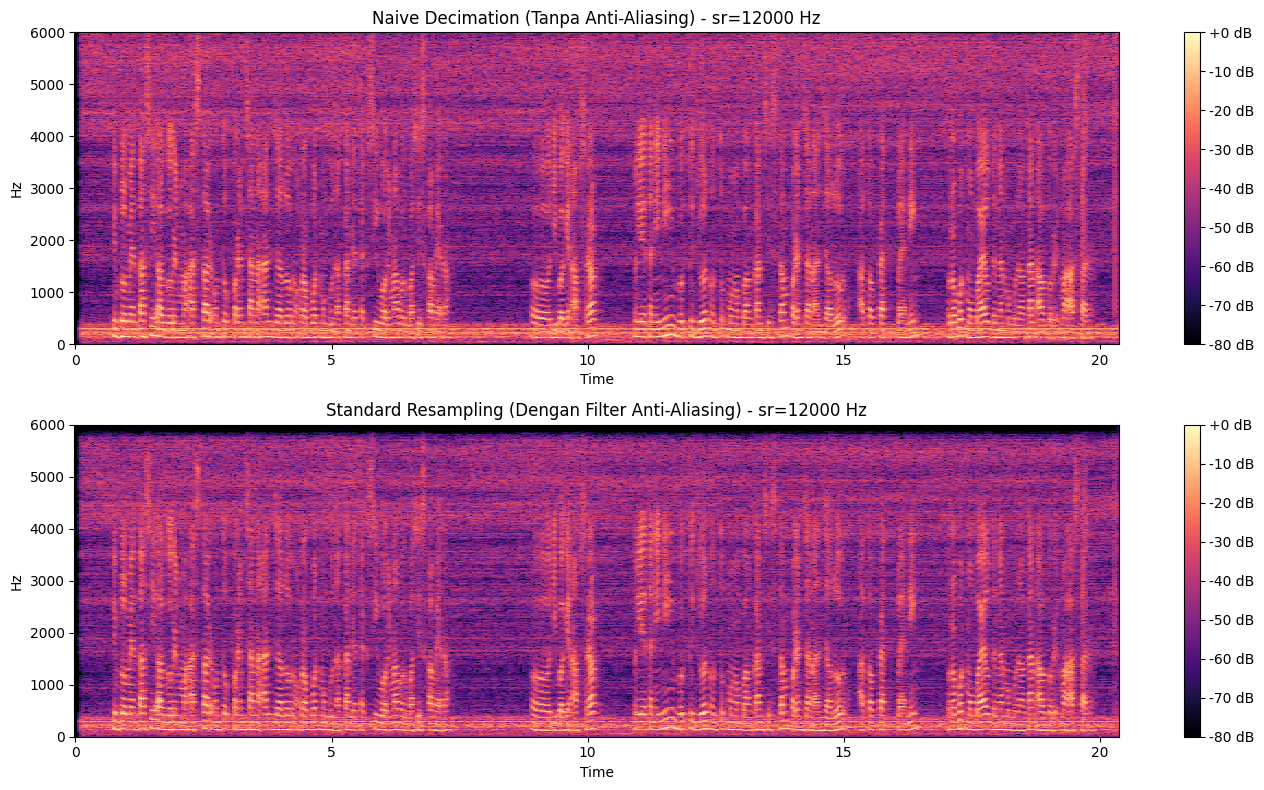

In [7]:
plt.figure(figsize=(14, 8))

# Spektrogram Naive
D_naive = librosa.stft(y_naive)
S_naive_db = librosa.amplitude_to_db(np.abs(D_naive), ref=np.max)

plt.subplot(2, 1, 1)
librosa.display.specshow(S_naive_db, sr=target_sr, x_axis='time', y_axis='hz')
plt.title(f'Naive Decimation (Tanpa Anti-Aliasing) - sr={target_sr} Hz')
plt.colorbar(format='%+2.0f dB')

# Spektrogram Clean
D_clean = librosa.stft(y_clean)
S_clean_db = librosa.amplitude_to_db(np.abs(D_clean), ref=np.max)

plt.subplot(2, 1, 2)
librosa.display.specshow(S_clean_db, sr=target_sr, x_axis='time', y_axis='hz')
plt.title(f'Standard Resampling (Dengan Filter Anti-Aliasing) - sr={target_sr} Hz')
plt.colorbar(format='%+2.0f dB')

plt.tight_layout()
plt.show()

**Analisis Bukti Aliasing:**
Berdasarkan komparasi visual spektrogram di atas, pada metode *Naive Decimation*, terdapat komponen *noise* frekuensi tinggi (yang seharusnya sudah di atas ambang *Nyquist limit* pada *sample rate* baru) yang melipat atau terpantul kembali (*spectral fold-back*) ke rentang frekuensi rendah dan menengah. Ini menciptakan distorsi dan pola artifak yang tidak ada di audio aslinya.
Sebaliknya, pada metode *Standard Resampling*, sinyal telah dilewatkan melalui *Low-Pass Filter* sebelum laju sampel diturunkan. Hal ini berhasil memblokir frekuensi tinggi sehingga area tersebut tampak lebih bersih dan murni dari pantulan *aliasing*.